In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #para poner histogramas juntos

# Estadística descriptiva

- En esta estadística, simplemente representamos datos manejables de de un conjunto de datos. No pretendemos realizar hipótesis, o extraer conclusiones más allá de los propios datos. 
- Distinguimos entre población, el conjunto de items para los que se estudian los datos y muestra que es parte de la población que se estudia. 

## Primer paso: preparación de los datos.
Se trata de recoger los datos de las muestras y prepararlos en un formato adecuado para su análisis.
1) Obtener los datos, o de un fichero o de un análisis de la web.
2) Analizar los datos (parsing), si se presentan en texto plano, XML, etc.
3) Limpiar los datos: muchas veces contienen registros incompletos, errores, etc. Normalmente se eliminan los registros incompletos o se ignoran.
4) Construir estructuras de datos orientada al estudio que necesitamos. Si la estructura de datos no puede almacenarse en la memoria, se construye una base de datos (database) en forma de diccionario (claves-valor)  que puede mapearse cuando se necesite.


# Ejemplo Adult

- Esta database pública, alojada en !(https://archive.ics.uci.edu/ml/datasets/Adult) , presenta datos financieros.
- Trabajaremos en el fichero de PyCharm ADULT_ejemplo.py 



In [14]:
def chr_int(a):
    """ Si es un número, lo devuelve. Si no devuelve -1 """
    if a.strip().isdigit():
        return int(a)
    else:
        return 0


file = open('adult.data', 'r')  # apertura del fichero

datos = []  # Base de datos
n = 0  # recuento de datos
for i in file:  # por cada fila del fichero de datos
    fila = i.split(",")  # divide en trozo las filas
    for j in range(0, len(fila)):
        fila[j] = fila[j].strip()  # necesario limpiar caracteres espacios en blanco o saltos de línea.
    try:
        datos.append([chr_int(fila[0]),
                      fila[1],
                      chr_int(fila[2]),
                      fila[3],
                      chr_int(fila[4]),
                      fila[5], fila[6], fila[7], fila[8], fila[9],
                      chr_int(fila[10]), chr_int(fila[11]), chr_int(fila[12]),
                      fila[13], fila[14]])
    except IndexError as e:
        print("Fin de fichero")

# En pantalla algunos datos.
for algunos in datos[0:10]:
    print(algunos)

Fin de fichero
[39, 'State-gov', 77516, 'Bachelors', 13, 'Never-married', 'Adm-clerical', 'Not-in-family', 'White', 'Male', 2174, 0, 40, 'United-States', '<=50K']
[50, 'Self-emp-not-inc', 83311, 'Bachelors', 13, 'Married-civ-spouse', 'Exec-managerial', 'Husband', 'White', 'Male', 0, 0, 13, 'United-States', '<=50K']
[38, 'Private', 215646, 'HS-grad', 9, 'Divorced', 'Handlers-cleaners', 'Not-in-family', 'White', 'Male', 0, 0, 40, 'United-States', '<=50K']
[53, 'Private', 234721, '11th', 7, 'Married-civ-spouse', 'Handlers-cleaners', 'Husband', 'Black', 'Male', 0, 0, 40, 'United-States', '<=50K']
[28, 'Private', 338409, 'Bachelors', 13, 'Married-civ-spouse', 'Prof-specialty', 'Wife', 'Black', 'Female', 0, 0, 40, 'Cuba', '<=50K']
[37, 'Private', 284582, 'Masters', 14, 'Married-civ-spouse', 'Exec-managerial', 'Wife', 'White', 'Female', 0, 0, 40, 'United-States', '<=50K']
[49, 'Private', 160187, '9th', 5, 'Married-spouse-absent', 'Other-service', 'Not-in-family', 'Black', 'Female', 0, 0, 16, 

## Construcción de los dataframes

In [15]:
# Se construye un dataframe en pandas
df = pd.DataFrame(datos)
# datos es una lista de listas, cada una con un registro. En el programa se han quitado espacios a cada
# dato leído del fichero, se han convertido en enteros los que eran números.
df.columns = ['edad', 'tipo de empleado', 'fnlwgt', 'educación', 'educación_n', 'estado civil', 'ocupación', 'relación',
              'carrera', 'sexo', 'ganancias', 'pérdidas', 'horas semana', 'país', 'ingresos']


<hr width: 80%>

### Agrupaciones

- Se han definido las columnas y en la tupla **df.shape** se almacena las filas y columnas del DataFrame.
<br></br>
    - contar = df.groupby('país').size()
    - print(contar.head())
<br></br>
- Agrupo por país, y calculo el número de filas que hay por cada país. 


In [6]:
print(df.shape)
contar = df.groupby('país').size()  # agrupo por países, y calculo cuántas filas hay por cada país
print(contar.head())  # muestro las cinco primeras.

(32561, 15)
país
?           583
Cambodia     19
Canada      121
China        75
Columbia     59
dtype: int64


<hr width: 80%>

### Sub dataframes

- Ahora quiero hacer subdataframes por sexo, y por sexo / ingresos. Observar las dos manera que hay para filtrar campos (**df.campo** y **df[‘campo’]**) . Observar los paréntesis.

In [7]:
# separamos los data frames por sexo, y por sexo y por nivel de ingresos
mdf = df[df['sexo'] == 'Male']
wdf = df[df['sexo'] == 'Female']
mdf1 = df[(df['sexo'] == 'Male') & (df['ingresos'] == '>50K')]
wdf1 = df[(df.sexo == 'Female') & (df.ingresos == '>50K')]
print(mdf.head(), wdf.head())

   edad  tipo de empleado  fnlwgt  educación  educación_n        estado civil  \
0    39         State-gov   77516  Bachelors           13       Never-married   
1    50  Self-emp-not-inc   83311  Bachelors           13  Married-civ-spouse   
2    38           Private  215646    HS-grad            9            Divorced   
3    53           Private  234721       11th            7  Married-civ-spouse   
7    52  Self-emp-not-inc  209642    HS-grad            9  Married-civ-spouse   

           ocupación       relación carrera  sexo  ganancias  pérdidas  \
0       Adm-clerical  Not-in-family   White  Male       2174         0   
1    Exec-managerial        Husband   White  Male          0         0   
2  Handlers-cleaners  Not-in-family   White  Male          0         0   
3  Handlers-cleaners        Husband   Black  Male          0         0   
7    Exec-managerial        Husband   White  Male          0         0   

   horas semana           país ingresos  
0            40  United-St

<hr>

### Medias, desviación típica, medianas, varianzas

- Hallamos porcentajes:   **int(10000 * mdf.shape[0] / df.shape[0]) / 100)**
- Otra forma:  **10000*len(wdf) / float(len(df) * 100) → con todos los decimales.**

#### Media
La media (mean) es la suma de todos los valores dividido entre el número de valores.  Suele usarse también en inglés la palabra average, aunque esta se usa en una forma más general y podría ser la mediana, u otro valor. 
- Por ejemplo: media de edades en un dataframe df → **df['edad'].mean()**

<center>$\mu = \bar{x} = \frac{1}{n} \cdot \sum_{i=1}^{n} x_{i}$</center>

#### Varianza y desviación típicas
Representa la media de las desviaciones al cuadrado respecto de la media (varianza) y su raíz cuadrada (desviación típica). 
- Por ejemplo → **df['edad'].var()** y **df['edad'].std()**

<center>$\sigma^2={\frac {1}{n}}\sum _{i=1}^{n}\left(x_{i}-{{\mu}}\right)^{2}$</center>

#### Medianas
Las medianas es el valor encontrado a la mitad de los datos cuando se ordenan todos de menor a mayor. Permite obviar el hecho de los errores atípicos (outlier) que sí afecta a la media. 
- Por ejemplo → **df['edad'].median()**

In [16]:
# Porcentajes. Pág 33. varias formas de verlo.
print("Porcentaje de hombres ({}) en datos ({}): {}%"
      .format( mdf.shape[0], df.shape[0],int(10000 * mdf.shape[0] / df.shape[0]) / 100))
print("Porcentaje de mujeres ({}) en datos ({}): {}%"
      .format(len(wdf), len(df), 10000 * len(wdf) / float(len(df) * 100)))
print("Porcentaje de mujeres con altas ganancias ({}) en datos ({}): {}%"
      .format(len(wdf1), len(df), 10000 * len(wdf1) / float(len(df) * 100)))
print("Porcentaje de hombres con altas ganancias ({}) en datos ({}): {}%"
      .format(len(mdf1), len(df), 10000 * len(mdf1) / float(len(df) * 100)))

# Medias. Pág 34
print("Media de las edades en el dataframe datos: {}".format(df['edad'].mean()))
print("Media de las edades de los hombres: {}".format(mdf['edad'].mean()))
print("Media de las edades de las mujeres: {}".format(wdf['edad'].mean()))
print("Media de las edades de los hombres con altas ganancias: {}".format(mdf1['edad'].mean()))
print("Media de las edades de las mujeres con altas ganancias: {}".format(wdf1['edad'].mean()))

# Varianzas y desviaciones típicas.
print("Media {}, Varianza {} y desviación típica {} de la edad en datos"
      .format(df['edad'].mean(), df['edad'].var(), df['edad'].std()))
print("Media {}, Varianza {} y desviación típica {} de la edad en hombres"
      .format(mdf['edad'].mean(), mdf['edad'].var(), mdf['edad'].std()))
print("Media {}, Varianza {} y desviación típica {} de la edad en mujeres"
      .format(wdf['edad'].mean(), wdf['edad'].var(), wdf['edad'].std()))
print("Media {}, Varianza {} y desviación típica {} de la edad en hombres con altas ganancias"
      .format(mdf1['edad'].mean(), mdf1['edad'].var(), mdf1['edad'].std()))
print("Media {}, Varianza {} y desviación típica {} de la edad en mujeres con altas ganancias"
      .format(wdf1['edad'].mean(), wdf1['edad'].var(), wdf1['edad'].std()))

# Medianas de las edades de los dataframes considerados.
print("Mediana de las edades en el dataframe datos: {}".format(df['edad'].median()))
print("Mediana de las edades de los hombres: {}".format(mdf['edad'].median()))
print("Mediana de las edades de las mujeres: {}".format(wdf['edad'].median()))
print("Mediana de las edades de los hombres con altas ganancias: {}".format(mdf1['edad'].median()))
print("Mediana de las edades de las mujeres con altas ganancias: {}".format(wdf1['edad'].median()))

# Cuartiles de los datos.
print("Resumen de datos estadísticos {}".format(df['edad'].describe()))

Porcentaje de hombres (21790) en datos (32561): 66.92%
Porcentaje de mujeres (10771) en datos (32561): 33.07945087681582%
Porcentaje de mujeres con altas ganancias (1179) en datos (32561): 3.6208961641227235%
Porcentaje de hombres con altas ganancias (6662) en datos (32561): 20.460059580479715%
Media de las edades en el dataframe datos: 38.58164675532078
Media de las edades de los hombres: 39.43354749885268
Media de las edades de las mujeres: 36.85823043357163
Media de las edades de los hombres con altas ganancias: 44.62578805163614
Media de las edades de las mujeres con altas ganancias: 42.125530110262936
Media 38.58164675532078, Varianza 186.0614002488016 y desviación típica 13.640432553581341 de la edad en datos
Media 39.43354749885268, Varianza 178.77375174529985 y desviación típica 13.370630192526448 de la edad en hombres
Media 36.85823043357163, Varianza 196.3837063948063 y desviación típica 14.013697099438332 de la edad en mujeres
Media 44.62578805163614, Varianza 109.9450667486

<hr>

### Cuantiles y percentiles

#### Cuantiles, percentiles, deciles, cuartil
- Si llamo **p** a una fracción de los datos (p entre 0 y 1), el p cuantil xp (o el p*100 percentil) es el valor en el que hay una fracción de valores igual o menor que p que los valores xi =< xp .
- La fracción 1-p son valores que xi  > xp 
- Son importantes el primer cuartil, segundo cuartil (mediana) y tercer cuartil (el percentil 25%, 50% y 75%) que vienen en el resumen de los datos obtenidos con .describe → **df['edad'].describe()**

<hr>

#### Distribución de datos en histogramas
- Resumir un conjunto de datos en sus valores estadísticos puede ser peligroso para llegar a conclusiones, ya que varios conjuntos de datos pueden coincidir en sus valores estadísticos. Es mejor hacerse una idea de su distribución y para ello es útil contar con una gráfica, llamada **histograma**. 
    - Nota: hay que instalar matplotlib (mejor desde PyCharm) e importarlo como objeto. 
    - Por ejemplo → **wdf['edad'].hist(density=False,histtype="stepfilled", bins=20)**
    - **density = True** (antes normed) eje Y en porcentajes, normalizado.. The normalized histogram is called the **Probability Mass Function (PMF).**
    - **bins** es el número de pasos. 
    - En PyCharm, debo acabar con **plt.show()** (librería matplotlib para mostrar las gráficas. ). Si llamo a dos histogramas, los pone juntos.
    - Parámetro alpha para darle transparencia… 


<AxesSubplot:>

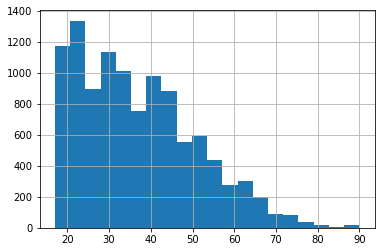

In [9]:
wdf['edad'].hist(density=False,histtype="stepfilled", bins=20)

<AxesSubplot:>

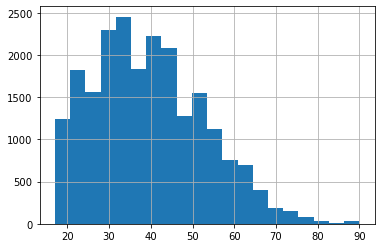

In [10]:
mdf['edad'].hist(density=False,histtype="stepfilled", bins=20)

<hr>

## Ejemplo de cómo poner dos gráficas a la vez

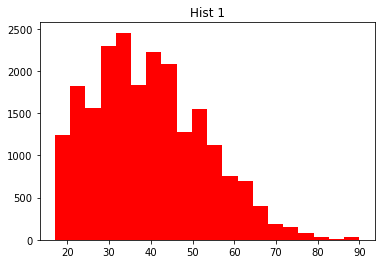

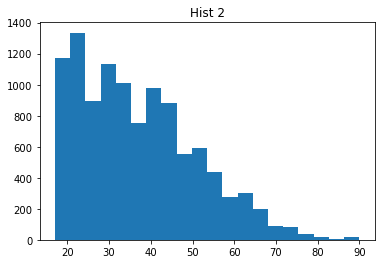

In [11]:
# Histograma
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

ax1.hist(mdf['edad'],density=False,histtype="stepfilled", bins=20,color="r")
ax1.set_title("Hist 1")
ax2.hist(wdf['edad'],density=False,histtype="stepfilled", bins=20)
ax2.set_title("Hist 2")

plt.show()

<hr>

## Dos gráficas superpuestas

<AxesSubplot:>

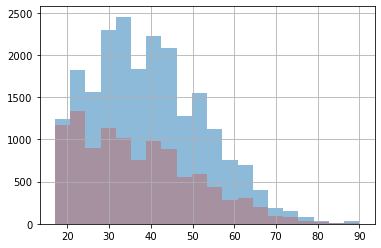

In [12]:

mdf['edad'].hist(density=False,histtype="stepfilled", bins=20,alpha=0.5)
wdf['edad'].hist(density=False,histtype="stepfilled", bins=20,alpha=0.5, color=sns.desaturate('indianred',0.75))

<hr>

### CDF

- Histogramas normalizados que muestra la probabilidad acumulada de que se encuentre el valor x o menor. Por ejemplo, con 40 años o menos es probable encontrar un hombre trabajando en un 62% aproximadamente y una mujer en un 68~70% . 

- Cumulative Distribution Function. Función de distribución acumulativa. Representa la probabilidad de que una variable cualquiera X **valga menos o igual que x**

<AxesSubplot:>

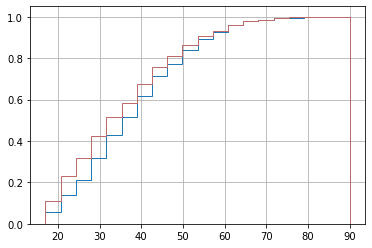

In [13]:
mdf['edad'].hist(density=True,histtype="step", bins=20,cumulative=True)
wdf['edad'].hist(density=True,histtype="step", bins=20,cumulative=True, color=sns.desaturate('indianred',0.75))